In [ ]:
import pandas as pd
import numpy as np
import io
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("lab1 data.csv")

In [ ]:
df.columns = [
    'Timestamp', 'Reg_No', 'Job_Role', 'Min_Salary', 'Max_Salary', 'Median_Salary',
    'Highest_Company', 'Extra_Curricular', 'Technical_Comp', 'Expected_Package',
    'CIA_Perc', 'GPA', 'Attendance', 'Internship_Interest'
]

In [ ]:
print("--- FIRST 10 RECORDS ---")
print(df.head(10))

print("\n--- DATASET METADATA ---")
print(df.info())

print("\n--- SUMMARY STATISTICS ---")
print(df.describe(include='all'))

--- FIRST 10 RECORDS ---
            Timestamp   Reg_No           Job_Role Min_Salary Max_Salary  \
0  12-4-2024 20:31:09  2341338     Data Scientist      3 LPA        1Cr   
1  12-4-2024 20:33:07  2341310     Data Scientist          5        NaN   
2  12-4-2024 20:39:43  2341311     Data Scientist      7 LPA     15 LPA   
3  12-4-2024 20:40:37  2341324     Data Scientist      3 LPA     25 LPA   
4  12-4-2024 20:41:51  2341324   Business Analyst          2         50   
5  12-4-2024 20:43:08  2341324      Data Engineer          3         30   
6  12-4-2024 20:44:02  2341324  Software Engineer          2         71   
7  12-4-2024 20:44:58  2341324  Software Engineer          3         77   
8  12-4-2024 21:06:41   13_007     Data Scientist          3         24   
9  12-4-2024 21:07:51   13_727  Software Engineer          2         15   

  Median_Salary Highest_Company  Extra_Curricular  Technical_Comp  \
0        20 LPA         Deolite               3.0               4   
1          

In [ ]:
print("Missing Values Per Column:")
print(df.isnull().sum())

Missing Values Per Column:
Timestamp               0
Reg_No                  0
Job_Role                1
Min_Salary              1
Max_Salary              5
Median_Salary           6
Highest_Company         1
Extra_Curricular        1
Technical_Comp          0
Expected_Package        1
CIA_Perc               11
GPA                     7
Attendance              5
Internship_Interest    25
dtype: int64


In [ ]:
duplicate_count = df.duplicated(subset=['Reg_No']).sum()
print(f"\nDuplicate rows based on Reg_No: {duplicate_count}")


Duplicate rows based on Reg_No: 13


In [ ]:
print("\nUnique Job Roles:")
print(df['Job_Role'].unique())


Unique Job Roles:
['Data Scientist' 'Business Analyst' 'Data Engineer' 'Software Engineer'
 nan]


In [ ]:
def clean_salary_column(val):
    if pd.isna(val):
        return np.nan
    val = str(val).lower().strip().replace(',', '')

    # Handle junk strings or non-numeric entries
    if 'morbillion' in val or 'na' in val or '-' in val:
        return np.nan

    # Extract numerical components
    num_match = re.search(r'[\d\.]+', val)
    if not num_match:
        return np.nan
    num = float(num_match.group())

    # Standardize scale to LPA
    if num >= 10000:          # e.g., 300000 -> 3.0 LPA
        return num / 100000
    if 'cr' in val:           # e.g., 1 Cr -> 100 LPA
        return num * 100
    return num

# Apply normalization across all financial columns
salary_cols = ['Min_Salary', 'Max_Salary', 'Median_Salary', 'Expected_Package']
for col in salary_cols:
    df[col] = df[col].apply(clean_salary_column)

In [ ]:
def clean_percentage(val):
    if pd.isna(val) or str(val).strip() in ['-', 'NA', 'ongoing', 'as of now 100']:
        return np.nan
    val = str(val).replace('%', '').strip()
    try:
        return float(val)
    except:
        return np.nan

df['CIA_Perc'] = df['CIA_Perc'].apply(clean_percentage)
df['Attendance'] = df['Attendance'].apply(clean_percentage)

def clean_gpa(val):
    if pd.isna(val) or str(val).strip() in ['-', 'NA', 'ongoing', '3/5', '3.3/4']:
        return np.nan
    val = str(val).replace('%', '').strip()
    try:
        num = float(val)
        # If the student wrote a percentage instead of a GPA scale (e.g. 92% -> 9.2 GPA)
        if num > 10:
            return num / 10
        return num
    except:
        return np.nan

df['GPA'] = df['GPA'].apply(clean_gpa)

In [ ]:
# Categorical string cleanup
df['Job_Role'] = df['Job_Role'].str.strip().replace({'Data Sci': 'Data Scientist'})
df['Internship_Interest'] = df['Internship_Interest'].str.strip()

# Datetime conversion
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')

# Drop duplicate records based on Registration Numbers
df = df.drop_duplicates(subset=['Reg_No'], keep='first')

In [ ]:
# Record data profile prior to final imputation for visualizations
missing_before_imputation = df.isnull().sum()

# Strategy 1: Listwise deletion for empty placeholder records (Keep rows with at least 8 valid features)
df = df.dropna(thresh=8)

# Strategy 2: Median Imputation for highly skewed salary & metric columns
skewed_numeric_cols = ['Min_Salary', 'Max_Salary', 'Median_Salary', 'Expected_Package', 'CIA_Perc', 'GPA', 'Attendance']
for col in skewed_numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Strategy 3: Mean Imputation for symmetric behavioral rating scales
df['Extra_Curricular'] = pd.to_numeric(df['Extra_Curricular'], errors='coerce')
df['Technical_Comp'] = pd.to_numeric(df['Technical_Comp'], errors='coerce')

df['Extra_Curricular'] = df['Extra_Curricular'].fillna(df['Extra_Curricular'].mean())
df['Technical_Comp'] = df['Technical_Comp'].fillna(df['Technical_Comp'].mean())

# Strategy 4: Mode Imputation for categorical placeholders
categorical_cols = ['Job_Role', 'Internship_Interest', 'Highest_Company']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

missing_after_imputation = df.isnull().sum()

In [ ]:
outlier_targets = ['Expected_Package', 'Attendance', 'GPA']

for col in outlier_targets:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the fence limits
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

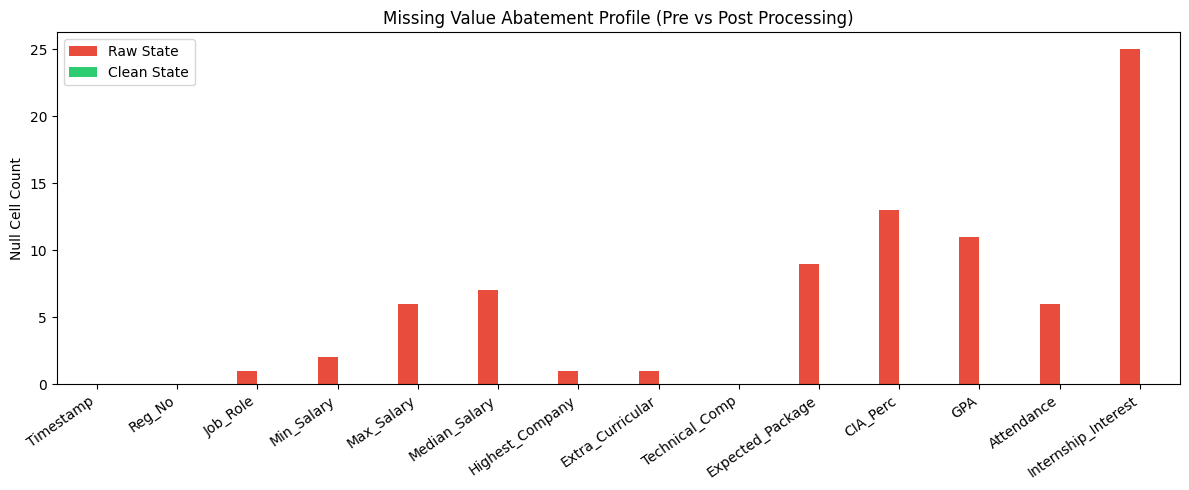

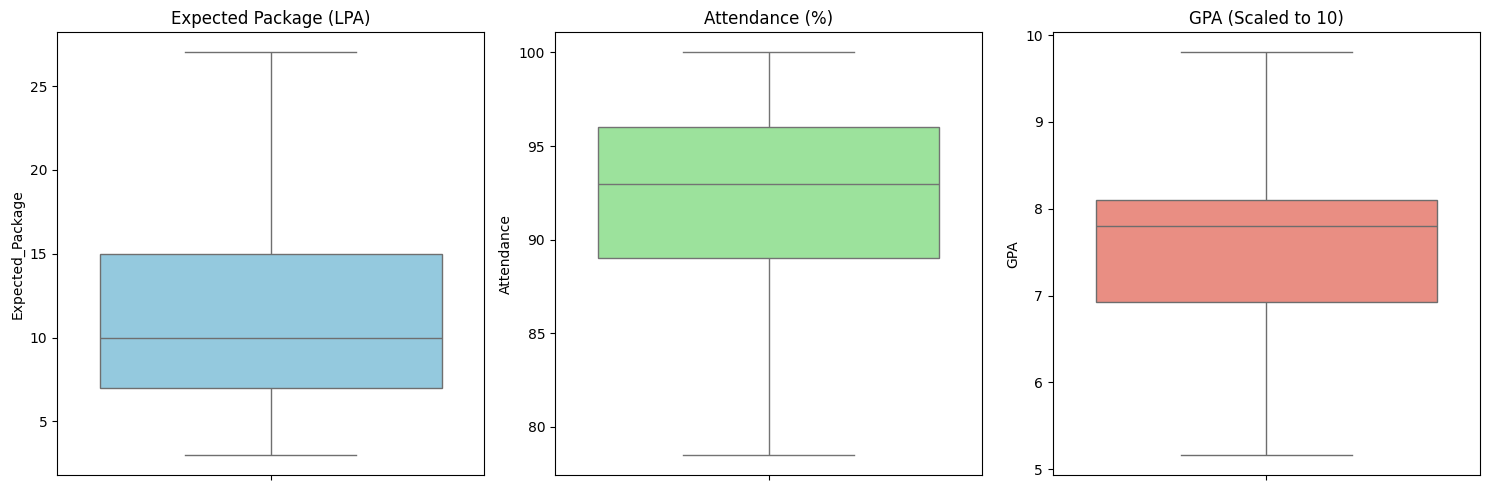

Data cleaning pipeline execution finished successfully.


In [ ]:
# 1. Plot Missing Value Metrics Comparison
missing_comparison = pd.DataFrame({
    'Raw State': missing_before_imputation,
    'Clean State': missing_after_imputation
})
missing_comparison.plot(kind='bar', figsize=(12, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Missing Value Abatement Profile (Pre vs Post Processing)')
plt.ylabel('Null Cell Count')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# 2. Post-Cleaning Outlier Assessment Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(y=df['Expected_Package'], ax=axes[0], color='skyblue').set_title('Expected Package (LPA)')
sns.boxplot(y=df['Attendance'], ax=axes[1], color='lightgreen').set_title('Attendance (%)')
sns.boxplot(y=df['GPA'], ax=axes[2], color='salmon').set_title('GPA (Scaled to 10)')
plt.tight_layout()
plt.show()

# Export clean analytics-ready file
df.to_csv("cleaned_student_survey.csv", index=False)
print("Data cleaning pipeline execution finished successfully.")

In [ ]:
#2nd DataSet (Titanic)
df = pd.read_csv("titanic-traindata.csv")

In [ ]:
print("\n[INFO] First 10 Rows of the Titanic Dataset:")
print(df.head(10))

print("\n[INFO] Last 10 Rows of the Titanic Dataset:")
print(df.tail(10))

print("\n[INFO] Titanic Dataset Structural Information (info()):")
print(df.info())

print("\n[INFO] Summary Statistics for All Numeric Fields (describe()):")
print(df.describe(include='all'))


[INFO] First 10 Rows of the Titanic Dataset:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                 

In [ ]:
missing_before = df.isnull().sum()

In [ ]:
# Report out raw missing values totals per column
print("[REPORT] Total missing values per feature column:")
print(missing_before)

# Track and report out duplicate records based on the unique identifier 'PassengerId'
duplicate_count = df.duplicated(subset=['PassengerId']).sum()
print(f"\n[REPORT] Duplicate records found based on PassengerId: {duplicate_count}")

# Check unique values in categorical columns to find formatting or structural issues
print("\n[REPORT] Unique variations within the 'Embarked' column:")
print(df['Embarked'].unique())

print("\n[REPORT] Unique variations within the 'Pclass' (Passenger Class) column:")
print(df['Pclass'].unique())

[REPORT] Total missing values per feature column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

[REPORT] Duplicate records found based on PassengerId: 0

[REPORT] Unique variations within the 'Embarked' column:
['S' 'C' 'Q' nan]

[REPORT] Unique variations within the 'Pclass' (Passenger Class) column:
[3 1 2]


In [ ]:
# Task 1: Standardize String/Text values (Wipe whitespaces and enforce uniform casing)
df['Sex'] = df['Sex'].str.strip().str.lower()
df['Embarked'] = df['Embarked'].str.strip().str.upper()

# Task 2: Drop structural columns with excessive text complexity that aren't numeric features
# 'Ticket' numbers and descriptive 'Name' arrays can be parsed, but let's drop duplicates safely based on ID
df = df.drop_duplicates(subset=['PassengerId'], keep='first')

print("[SUCCESS] Data strings stripped/cleaned and unique constraints validated.")

[SUCCESS] Data strings stripped/cleaned and unique constraints validated.


In [ ]:
# Strategy 1: High Missing Value Dropping (Drop 'Cabin' column as it is >70% null entries)
if 'Cabin' in df.columns:
    df = df.drop(columns=['Cabin'])
    print("[TECHNIQUE 1] Dropped 'Cabin' column due to an excessive missing data ratio.")

# Strategy 2: Median Imputation (Used for heavily skewed numeric features like Age)
# Median preserves the distribution center without being pulled by extreme outliers.
df['Age'] = df['Age'].fillna(df['Age'].median())
print("[TECHNIQUE 2] Imputed missing 'Age' rows using the feature distribution's Median.")

# Strategy 3: Mean Imputation (Used for balanced numeric financial scales like Fare)
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())
print("[TECHNIQUE 3] Imputed missing 'Fare' points using the overall feature Mean.")

# Strategy 4: Mode Imputation (Used for string categorical columns like Embarked port codes)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print("[TECHNIQUE 4] Imputed missing 'Embarked' categorical cells using the highest frequency Mode.")

# Trace missing values post-imputation to confirm completeness
missing_after = df.isnull().sum()

[TECHNIQUE 2] Imputed missing 'Age' rows using the feature distribution's Median.
[TECHNIQUE 3] Imputed missing 'Fare' points using the overall feature Mean.
[TECHNIQUE 4] Imputed missing 'Embarked' categorical cells using the highest frequency Mode.


In [ ]:
# Define continuous numerical columns prone to extreme outlier parameters
outlier_targets = ['Fare', 'Age']

for col in outlier_targets:
    # Compute operational Interquartile Ranges (IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Soft-capping via np.where clamps anomalous values to the outer fence bounds
    # ensuring distribution consistency without entirely erasing records from the set.
    df[col] = np.where(df[col] > upper_bound, upper_bound, df[col])
    df[col] = np.where(df[col] < lower_bound, lower_bound, df[col])

print("[SUCCESS] Continuous numeric outliers processed and soft-capped inside IQR bounds.")

[SUCCESS] Continuous numeric outliers processed and soft-capped inside IQR bounds.



PART F: VISUALIZATION & OUTPUT


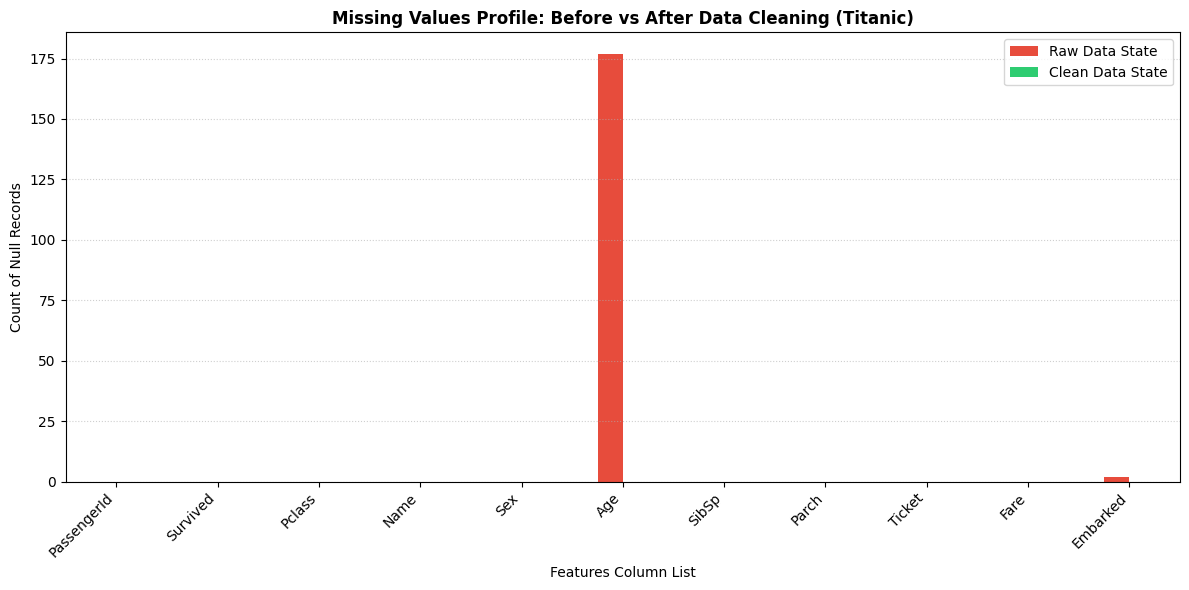

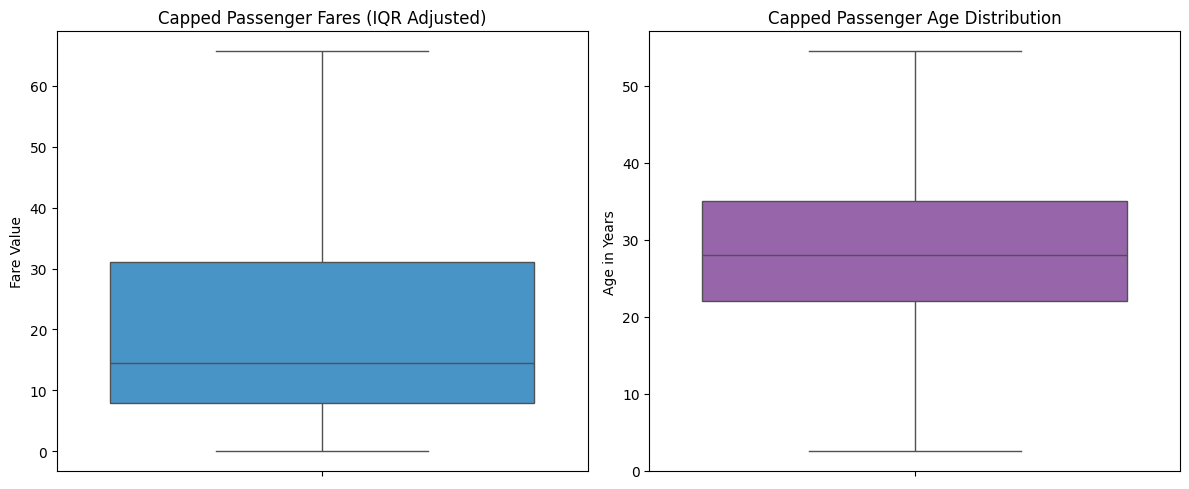

In [ ]:
print("\n" + "="*80)
print("PART F: VISUALIZATION & OUTPUT")
print("="*80)

# Visual Plot 1: Comparative bar chart tracking missing cell quantities pre- vs post-clean
# Align missing columns manually since 'Cabin' was dropped during Part D
missing_before_aligned = missing_before.drop('Cabin', errors='ignore')
missing_after_aligned = missing_after

missing_comparison_df = pd.DataFrame({
    'Raw Data State': missing_before_aligned,
    'Clean Data State': missing_after_aligned
})

missing_comparison_df.plot(kind='bar', figsize=(12, 6), color=['#e74c3c', '#2ecc71'])
plt.title('Missing Values Profile: Before vs After Data Cleaning (Titanic)', fontsize=12, fontweight='bold')
plt.ylabel('Count of Null Records')
plt.xlabel('Features Column List')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# Visual Plot 2: Cleaned continuous variable assessment boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Fare'], color='#3498db')
plt.title('Capped Passenger Fares (IQR Adjusted)')
plt.ylabel('Fare Value')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Age'], color='#9b59b6')
plt.title('Capped Passenger Age Distribution')
plt.ylabel('Age in Years')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv("cleaned_titanic_output.csv", index=False)